# GRID Auction Simulations

Quick smoke tests for the GRID instance generator and heuristic solver. The
focus is on how much slack is needed and whether boosting gets used.

In [5]:
from time import perf_counter

import numpy as np
import pandas as pd

from GRID_generation import generate_grid_instance
from GRID_heuristic import run_grid_heuristic
from GRID_viz import draw_grid_solution

rng = np.random.default_rng(0)

In [6]:
# Simulation parameters
grid_sizes = [5, 7]
player_counts = [5, 8, 12, 20]
path_lengths = [2, 3, 4]
num_trials = 5

max_cap = 3
max_budget = 20
max_utility = 15

heuristic_kwargs = {
    "max_rounds": 200,
    "delta": 0.5,
    "epsilon_scale": 0.1,
    "price_floor": 0.0,
}

In [7]:
results = []

for n in grid_sizes:
    for m in player_counts:
        for C in path_lengths:
            for trial in range(num_trials):
                seed = int(rng.integers(0, 1_000_000))
                instance = generate_grid_instance(
                    n=n,
                    m=m,
                    C=C,
                    max_cap=max_cap,
                    max_budget=max_budget,
                    max_utility=max_utility,
                    rng_seed=seed,
                )

                start = perf_counter()
                result = run_grid_heuristic(instance, rng_seed=seed, **heuristic_kwargs)
                history = result.get("meta", {}).get("history", [])
                if history:
                    avg_change_rate = sum(h.get("demand_change_rate", 0.0) for h in history) / len(history)
                    avg_max_price = sum(h.get("max_price", 0.0) for h in history) / len(history)
                    avg_price_std = sum(h.get("price_std", 0.0) for h in history) / len(history)
                else:
                    avg_change_rate = 0.0
                    avg_max_price = 0.0
                    avg_price_std = 0.0
                elapsed = perf_counter() - start

                results.append(
                    {
                        "grid": n,
                        "players": m,
                        "C": C,
                        "trial": trial,
                        "slack_found": result.get("slack"),
                        "boosted": result.get("is_boosted", False),
                        "equilibrium": result.get("equilibrium", False),
                        "rounds": result.get("rounds"),
                        "delta_final": result.get("delta"),
                        "time_sec": elapsed,
                        "avg_demand_change": avg_change_rate,
                        "avg_max_price": avg_max_price,
                        "avg_price_std": avg_price_std,
                    }
                )
        print(f"Completed grid size {n} with {m} players")
df = pd.DataFrame(results) 
df.head()

Completed grid size 5 with 5 players
Completed grid size 5 with 8 players
Completed grid size 5 with 12 players
Completed grid size 5 with 20 players
Completed grid size 7 with 5 players
Completed grid size 7 with 8 players
Completed grid size 7 with 12 players
Completed grid size 7 with 20 players


,grid,players,C,trial,slack_found,boosted,equilibrium,rounds,delta_final,time_sec,avg_demand_change,avg_max_price,avg_price_std
0,5,5,2,0,0,True,True,74,0.25,3.229308,0.493151,4.001099,1.529831
1,5,5,2,1,1,False,True,14,0.50,8.931637,0.603756,6.149723,2.006252
2,5,5,2,2,0,False,True,12,0.50,0.392432,0.272727,3.000000,1.120711
3,5,5,2,3,0,False,True,13,0.50,0.522445,0.383333,3.250000,1.139177
4,5,5,2,4,0,False,True,22,0.50,0.813435,0.266667,5.000000,1.602931


In [8]:
# Summary statistics
summary = (
    df.groupby(["grid", "players", "C"])
    .agg(
        runs=("trial", "count"),
        eq_rate=("equilibrium", "mean"),
        avg_slack=("slack_found", "mean"),
        boost_rate=("boosted", "mean"),
        avg_rounds=("rounds", "mean"),
    )
    .reset_index()
)
summary

,grid,players,C,runs,eq_rate,avg_slack,boost_rate,avg_rounds
0,5,5,2,5,1.0,0.2,0.2,27.0
1,5,5,3,5,1.0,0.0,0.2,32.0
2,5,5,4,5,1.0,0.2,0.0,16.2
3,5,8,2,5,1.0,0.6,0.2,27.8
4,5,8,3,5,1.0,0.4,0.2,36.0
5,5,8,4,5,1.0,0.4,0.2,36.4
6,5,12,2,5,1.0,0.2,0.4,46.0
7,5,12,3,5,1.0,0.6,0.0,15.8
8,5,12,4,5,1.0,0.8,0.0,18.2
9,5,20,2,5,1.0,0.4,0.2,35.8


In [9]:
# Distribution of minimal slack required
slack_dist = df.pivot_table(
    values="trial",
    index=["grid", "players", "C"],
    columns="slack_found",
    aggfunc="count",
    fill_value=0,
)
slack_dist

slack_found     0  1
grid players C      
5    5       2  4  1
             3  5  0
             4  4  1
     8       2  2  3
             3  3  2
             4  3  2
     12      2  4  1
             3  2  3
             4  1  4
     20      2  3  2
             3  1  4
             4  1  4
7    5       2  4  1
             3  5  0
             4  4  1
     8       2  2  3
             3  4  1
             4  3  2
     12      2  0  5
             3  3  2
             4  0  5
     20      2  1  4
             3  0  5
             4  2  3

## Visualize a sample outcome

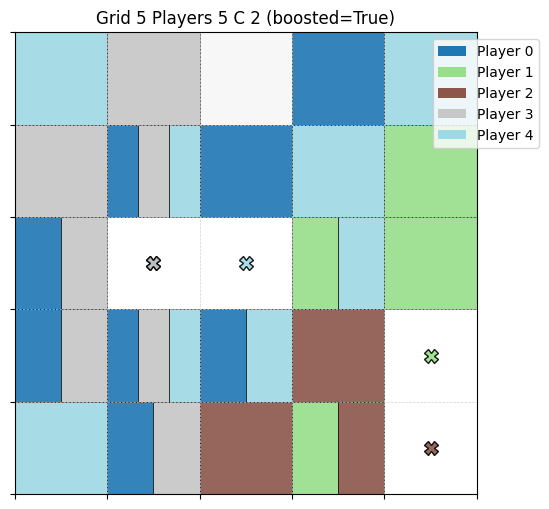

In [10]:
# Pick one run to visualize
if not df.empty:
    row = df.iloc[0]
    viz_seed = int(rng.integers(0, 1_000_000))
    viz_instance = generate_grid_instance(
        n=int(row["grid"]),
        m=int(row["players"]),
        C=int(row["C"]),
        max_cap=max_cap,
        max_budget=max_budget,
        max_utility=max_utility,
        rng_seed=viz_seed,
    )
    viz_result = run_grid_heuristic(viz_instance, rng_seed=viz_seed, **heuristic_kwargs)
    draw_grid_solution(
        viz_instance,
        viz_result,
        title=f"Grid {row['grid']} Players {row['players']} C {row['C']} (boosted={viz_result.get('is_boosted')})",
    );


In [11]:
# Save results table
output_csv = "grid_simulation_results.csv"
df.to_csv(output_csv, index=False)
print(f"Saved results to {output_csv}")


Saved results to grid_simulation_results.csv


Saved grid_max_slack.png
Saved grid_avg_slack.png


(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Average Slack Needed vs C'}, xlabel='C', ylabel='Avg Slack'>)

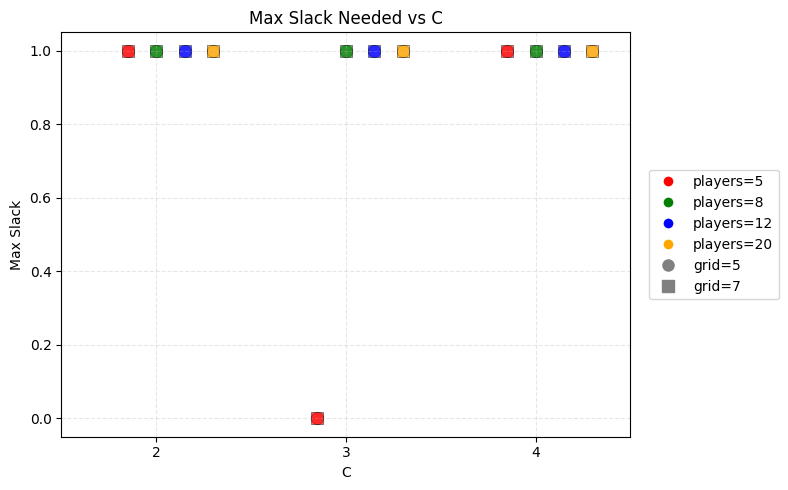

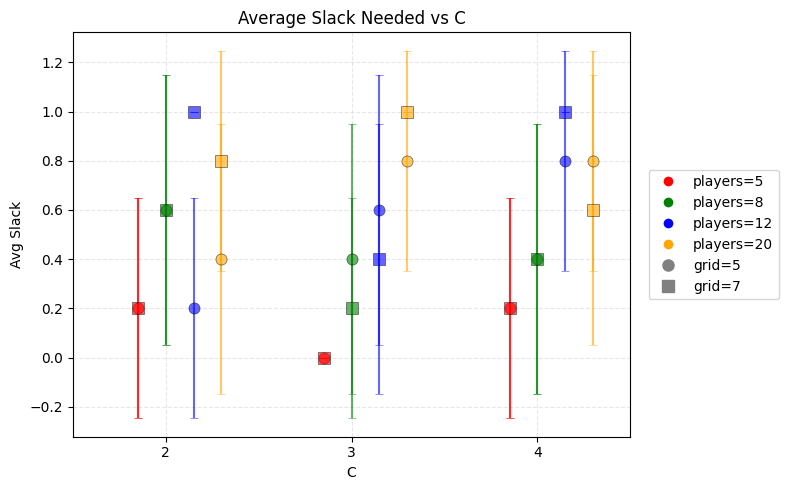

In [15]:
# Plot slack vs C (avg and max) with 2-sigma error bars on averages
import matplotlib.pyplot as plt

# Use only successful runs for slack stats
df_ok = df[df["equilibrium"]].copy()

# Aggregate slack by grid size, player count, and C
agg = (
    df_ok.groupby(["grid", "players", "C"])
    .agg(
        avg_slack=("slack_found", "mean"),
        max_slack=("slack_found", "max"),
        std_slack=("slack_found", "std"),
        n=("slack_found", "count"),
    )
    .reset_index()
)

player_sizes = sorted(df["players"].unique())[:4]
grid_sizes = sorted(df["grid"].unique())[:2]

color_map = {player_sizes[0]: "red", player_sizes[1]: "green", player_sizes[2]: "blue", player_sizes[3]: "orange"}
marker_map = {grid_sizes[0]: "o", grid_sizes[1]: "s"}

# Horizontal offsets for the three player sizes
offsets = {player_sizes[0]: -0.15, player_sizes[1]: 0.0, player_sizes[2]: 0.15, player_sizes[3]: 0.3}
def _plot_slack(metric, title, filename, with_error=False):
    fig, ax = plt.subplots(figsize=(8, 5))
    for grid in grid_sizes:
        for players in player_sizes:
            subset = agg[(agg["grid"] == grid) & (agg["players"] == players)]
            if subset.empty:
                continue
            xs = subset["C"].to_numpy(dtype=float) + offsets[players]
            ys = subset[metric].to_numpy(dtype=float)
            if with_error:
                errs = 1.0 * subset["std_slack"].fillna(0.0).to_numpy(dtype=float)
                ax.errorbar(
                    xs,
                    ys,
                    yerr=errs,
                    fmt=marker_map[grid],
                    color=color_map[players],
                    alpha=0.6,
                    markersize=8,
                    markeredgecolor="black",
                    markeredgewidth=0.5,
                    capsize=3,
                    linestyle="None",
                )
            else:
                ax.scatter(
                    xs,
                    ys,
                    c=color_map[players],
                    marker=marker_map[grid],
                    alpha=0.6,
                    s=80,
                    edgecolor="black",
                    linewidth=0.5,
                )
    ax.set_xlabel("C")
    ax.set_ylabel(metric.replace("_", " ").title())
    ax.set_title(title)
    ax.set_xticks(sorted(df["C"].unique()))
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.set_xlim(min(df["C"].unique()) - 0.5, max(df["C"].unique()) + 0.5)

    # Legends for colors (players) and markers (grid sizes)
    color_handles = [
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=color_map[p],
                   label=f"players={p}", markersize=8)
        for p in player_sizes
    ]
    marker_handles = [
        plt.Line2D([0], [0], marker=marker_map[g], color="gray", linestyle="None",
                   label=f"grid={g}", markersize=8)
        for g in grid_sizes
    ]
    ax.legend(handles=color_handles + marker_handles, loc="center left", bbox_to_anchor=(1.02, 0.5))

    fig.tight_layout()
    fig.savefig(filename, dpi=200)
    print(f"Saved {filename}")

    return fig, ax

_plot_slack("max_slack", "Max Slack Needed vs C", "grid_max_slack.png")
_plot_slack("avg_slack", "Average Slack Needed vs C", "grid_avg_slack.png", with_error=True)


Saved grid_5_avg_slack_vs_players_ci95.png
Saved grid_7_avg_slack_vs_players_ci95.png


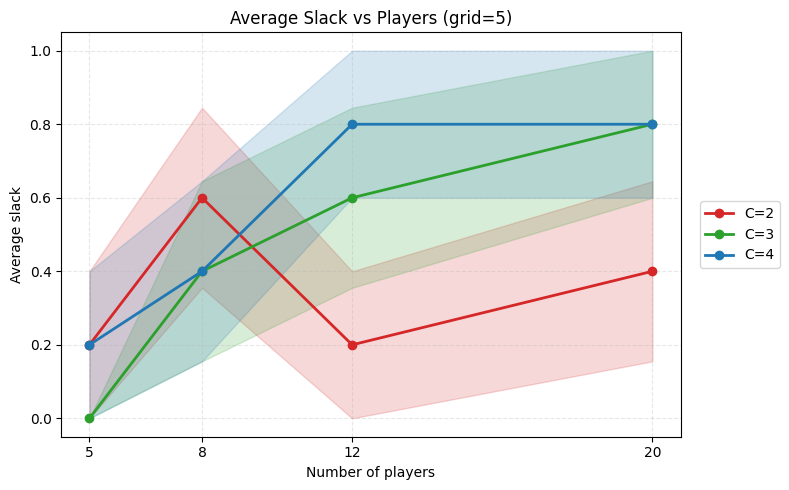

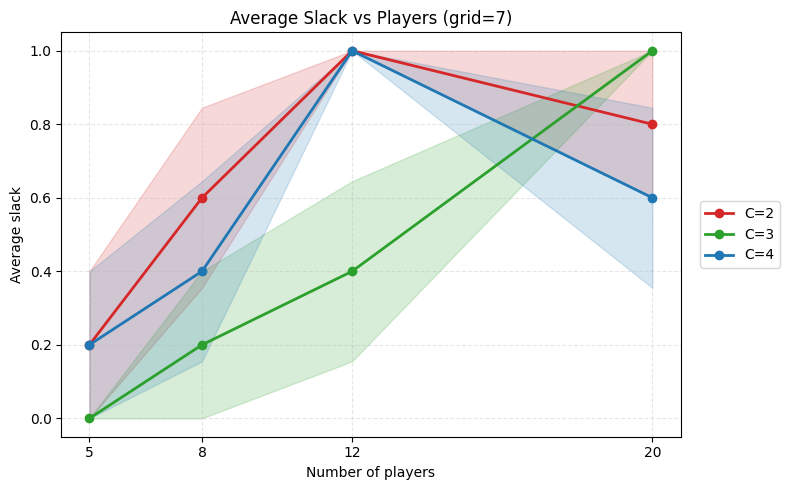

In [ ]:
# Per-grid avg slack vs players, with one line per C and 95% CI bands
import matplotlib.pyplot as plt
import numpy as np

line_colors = ["#d62728", "#2ca02c", "#1f77b4"]
all_C = sorted(df["C"].unique())[:3]
all_players = sorted(df["players"].unique())

line_stats = (
    df_ok.groupby(["grid", "players", "C"])
    .agg(
        avg_slack=("slack_found", "mean"),
        std_slack=("slack_found", "std"),
        n=("slack_found", "count"),
    )
    .reset_index()
)

for g in grid_sizes:
    fig, ax = plt.subplots(figsize=(8, 5))

    for idx, c_val in enumerate(all_C):
        subset = line_stats[(line_stats["grid"] == g) & (line_stats["C"] == c_val)].copy()
        if subset.empty:
            continue
        subset = subset.sort_values("players")
        xs = subset["players"].to_numpy(dtype=float)
        ys = subset["avg_slack"].to_numpy(dtype=float)
        stds = subset["std_slack"].fillna(0.0).to_numpy(dtype=float)
        ns = subset["n"].to_numpy(dtype=float)

        # 68% normal CI around mean: mean +/- 1.00 * std/sqrt(n)
        ci = np.where(ns > 0, 1.00 * stds / np.sqrt(ns), 0.0)
        lower = ys - ci
        upper = ys + ci

        ax.plot(
            xs,
            ys,
            marker="o",
            linewidth=2.0,
            color=line_colors[idx % len(line_colors)],
            label=f"C={c_val}",
        )
        ax.fill_between(
            xs,
            lower,
            upper,
            color=line_colors[idx % len(line_colors)],
            alpha=0.18,
        )

    ax.set_title(f"Average Slack vs Players (grid={g})")
    ax.set_xlabel("Number of players")
    ax.set_ylabel("Average slack")
    ax.set_xticks(all_players)
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
    fig.tight_layout()
    out_name = f"grid_{g}_avg_slack_vs_players_ci95.png"
    fig.savefig(out_name, dpi=200)
    print(f"Saved {out_name}")


Saved grid_eq_rate.png
Saved grid_boost_rate.png
Saved grid_avg_rounds.png
Saved grid_avg_time.png


(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Average Runtime (s) vs C'}, xlabel='C', ylabel='Avg Time'>)

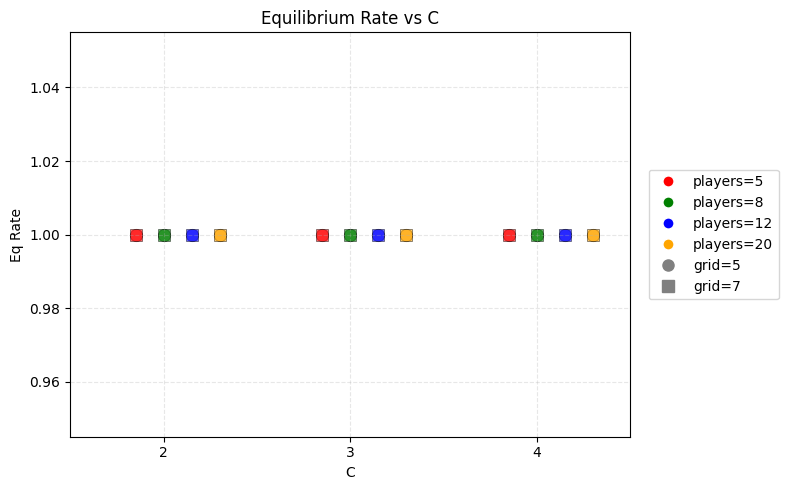

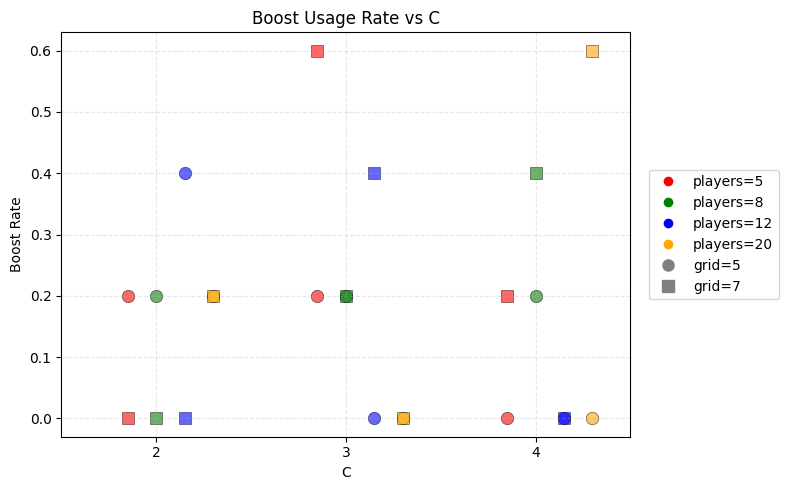

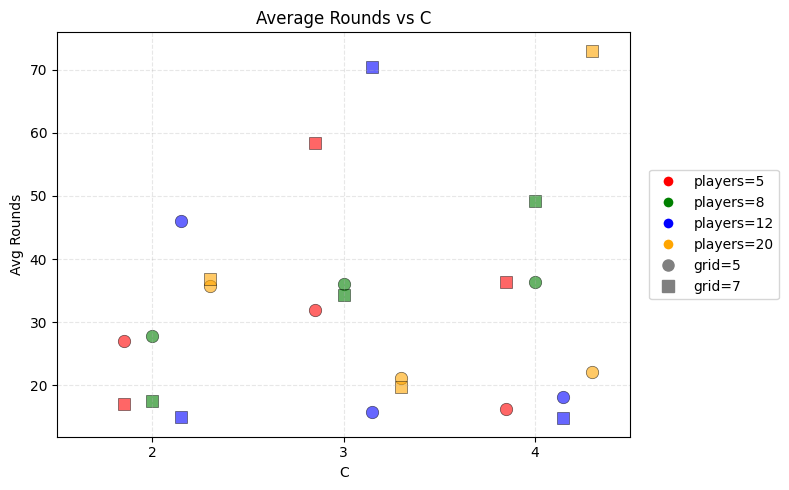

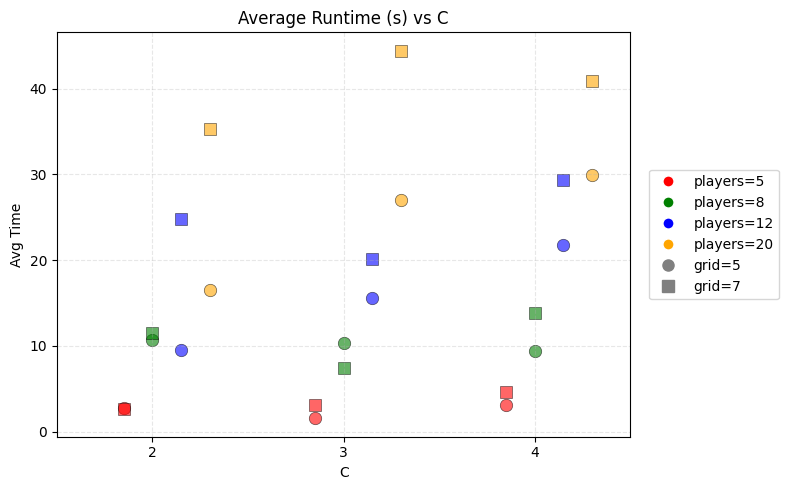

In [18]:
# Additional performance plots
import matplotlib.pyplot as plt

perf = (
    df.groupby(["grid", "players", "C"])
    .agg(
        eq_rate=("equilibrium", "mean"),
        boost_rate=("boosted", "mean"),
        avg_rounds=("rounds", "mean"),
        avg_time=("time_sec", "mean"),
    )
    .reset_index()
)

def _legend_handles():
    color_handles = [
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=color_map[p],
                   label=f"players={p}", markersize=8)
        for p in player_sizes
    ]
    marker_handles = [
        plt.Line2D([0], [0], marker=marker_map[g], color="gray", linestyle="None",
                   label=f"grid={g}", markersize=8)
        for g in grid_sizes
    ]
    return color_handles + marker_handles

def _plot_metric(metric, title, filename):
    fig, ax = plt.subplots(figsize=(8, 5))
    for grid in grid_sizes:
        for players in player_sizes:
            subset = perf[(perf["grid"] == grid) & (perf["players"] == players)]
            if subset.empty:
                continue
            xs = subset["C"].to_numpy(dtype=float) + offsets[players]
            ys = subset[metric].to_numpy(dtype=float)
            ax.scatter(
                xs,
                ys,
                c=color_map[players],
                marker=marker_map[grid],
                alpha=0.6,
                s=80,
                edgecolor="black",
                linewidth=0.5,
            )
    ax.set_xlabel("C")
    ax.set_ylabel(metric.replace("_", " ").title())
    ax.set_title(title)
    ax.set_xticks(sorted(df["C"].unique()))
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.set_xlim(min(df["C"].unique()) - 0.5, max(df["C"].unique()) + 0.5)
    ax.legend(handles=_legend_handles(), loc="center left", bbox_to_anchor=(1.02, 0.5))
    fig.tight_layout()
    fig.savefig(filename, dpi=200)
    print(f"Saved {filename}")
    return fig, ax

_plot_metric("eq_rate", "Equilibrium Rate vs C", "grid_eq_rate.png")
_plot_metric("boost_rate", "Boost Usage Rate vs C", "grid_boost_rate.png")
_plot_metric("avg_rounds", "Average Rounds vs C", "grid_avg_rounds.png")
_plot_metric("avg_time", "Average Runtime (s) vs C", "grid_avg_time.png")


Saved grid_avg_demand_change.png
Saved grid_avg_max_price.png
Saved grid_avg_price_std.png


(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Average Price Std Dev vs C'}, xlabel='C', ylabel='Avg Price Std'>)

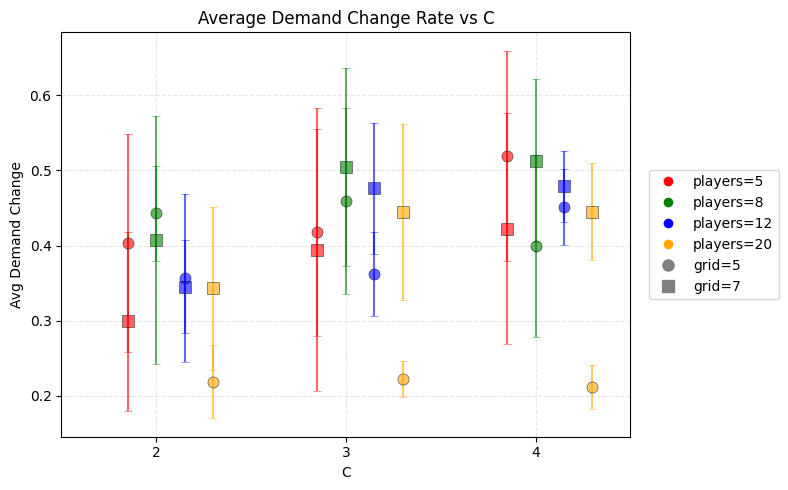

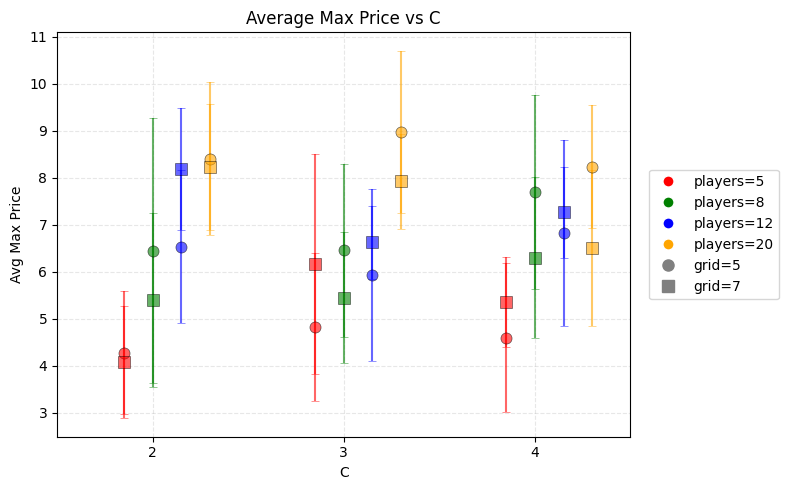

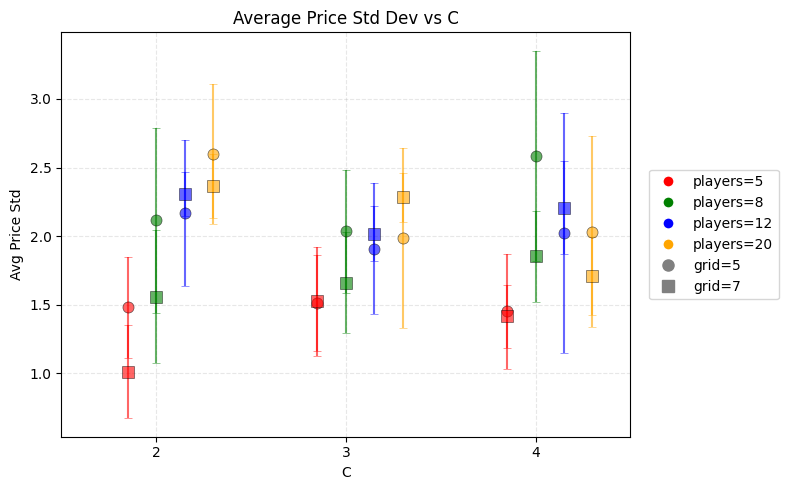

In [20]:
# Demand/price dynamics plots
import matplotlib.pyplot as plt

dyn = (
    df.groupby(["grid", "players", "C"])
    .agg(
        avg_demand_change=("avg_demand_change", "mean"),
        std_demand_change=("avg_demand_change", "std"),
        avg_max_price=("avg_max_price", "mean"),
        std_max_price=("avg_max_price", "std"),
        avg_price_std=("avg_price_std", "mean"),
        std_price_std=("avg_price_std", "std"),
    )
    .reset_index()
)

std_col_map = {
    "avg_demand_change": "std_demand_change",
    "avg_max_price": "std_max_price",
    "avg_price_std": "std_price_std",
}

def _plot_dyn(metric, title, filename):
    fig, ax = plt.subplots(figsize=(8, 5))
    for grid in grid_sizes:
        for players in player_sizes:
            subset = dyn[(dyn["grid"] == grid) & (dyn["players"] == players)]
            if subset.empty:
                continue
            xs = subset["C"].to_numpy(dtype=float) + offsets[players]
            ys = subset[metric].to_numpy(dtype=float)
            errs = subset[std_col_map[metric]].fillna(0.0).to_numpy(dtype=float)
            ax.errorbar(
                xs,
                ys,
                yerr=errs,
                fmt=marker_map[grid],
                color=color_map[players],
                alpha=0.6,
                markersize=8,
                markeredgecolor="black",
                markeredgewidth=0.5,
                linestyle="None",
                capsize=3,
            )
    ax.set_xlabel("C")
    ax.set_ylabel(metric.replace("_", " ").title())
    ax.set_title(title)
    ax.set_xticks(sorted(df["C"].unique()))
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.set_xlim(min(df["C"].unique()) - 0.5, max(df["C"].unique()) + 0.5)
    ax.legend(handles=_legend_handles(), loc="center left", bbox_to_anchor=(1.02, 0.5))
    fig.tight_layout()
    fig.savefig(filename, dpi=200)
    print(f"Saved {filename}")
    return fig, ax

_plot_dyn("avg_demand_change", "Average Demand Change Rate vs C", "grid_avg_demand_change.png")
_plot_dyn("avg_max_price", "Average Max Price vs C", "grid_avg_max_price.png")
_plot_dyn("avg_price_std", "Average Price Std Dev vs C", "grid_avg_price_std.png")
